In [1]:
import numpy as np
# Define the dataset
X = np.array([
    [0, 0],  # No suspicious keywords, known sender -> Not Spam
    [1, 0],  # Suspicious keywords, known sender -> Not Spam (e.g., promotional email)
    [0, 1],  # No suspicious keywords, unknown sender -> Spam
    [1, 1]   # Suspicious keywords, unknown sender -> Spam
])

y = np.array([0,1,1,1])

print("Input data:")
print(X)
print("\nOutput data:")
print(y)

Input data:
[[0 0]
 [1 0]
 [0 1]
 [1 1]]

Output data:
[0 1 1 1]


In [2]:
w = np.zeros(2)
b = 0
learning_rate = 0.1
epochs = 10

print("Weights for OR gate:", w)
print("Bias for OR gate:", b)

Weights for OR gate: [0. 0.]
Bias for OR gate: 0


In [3]:
def step_function(z):
  return 1 if z>=0 else 0

In [4]:
for epoch in range(epochs):
  print(f"\nEpoch {epoch+1}")
  for i in range(len(X)):
    # 1. Compute Weighted sum
    z = np.dot(w, X[i]) + b

    # 2. Apply Activation function
    y_pred = step_function(z)

    # 3. Compute Error
    error = y[i] - y_pred

    # Only update weights and bias if there's an error
    if error != 0:
      # 4. Update Weights
      w = w + learning_rate * error * X[i]

      # 5. Update Bias
      b = b + learning_rate * error

    print(f"Input: {X[i]}, Predicted: {y_pred}, Actual: {y[i]}, Weights:{w}, Bias: {b}")


Epoch 1
Input: [0 0], Predicted: 1, Actual: 0, Weights:[0. 0.], Bias: -0.1
Input: [1 0], Predicted: 0, Actual: 1, Weights:[0.1 0. ], Bias: 0.0
Input: [0 1], Predicted: 1, Actual: 1, Weights:[0.1 0. ], Bias: 0.0
Input: [1 1], Predicted: 1, Actual: 1, Weights:[0.1 0. ], Bias: 0.0

Epoch 2
Input: [0 0], Predicted: 1, Actual: 0, Weights:[0.1 0. ], Bias: -0.1
Input: [1 0], Predicted: 1, Actual: 1, Weights:[0.1 0. ], Bias: -0.1
Input: [0 1], Predicted: 0, Actual: 1, Weights:[0.1 0.1], Bias: 0.0
Input: [1 1], Predicted: 1, Actual: 1, Weights:[0.1 0.1], Bias: 0.0

Epoch 3
Input: [0 0], Predicted: 1, Actual: 0, Weights:[0.1 0.1], Bias: -0.1
Input: [1 0], Predicted: 1, Actual: 1, Weights:[0.1 0.1], Bias: -0.1
Input: [0 1], Predicted: 1, Actual: 1, Weights:[0.1 0.1], Bias: -0.1
Input: [1 1], Predicted: 1, Actual: 1, Weights:[0.1 0.1], Bias: -0.1

Epoch 4
Input: [0 0], Predicted: 0, Actual: 0, Weights:[0.1 0.1], Bias: -0.1
Input: [1 0], Predicted: 1, Actual: 1, Weights:[0.1 0.1], Bias: -0.1
Input

In [5]:
print("\nFinal Weights for OR gate:", w)
print("Final Bias for OR gate:", b)


Final Weights for OR gate: [0.1 0.1]
Final Bias for OR gate: -0.1


In [6]:
print("Testing the trained OR gate perceptron:")
for i in range(len(X)):
  test_input = X[i]
  predicted_output = step_function(np.dot(w, test_input) + b)
  actual_output = y[i]
  print(f"Input: {test_input}, Predicted: {predicted_output}, Actual: {actual_output}")

Testing the trained OR gate perceptron:
Input: [0 0], Predicted: 0, Actual: 0
Input: [1 0], Predicted: 1, Actual: 1
Input: [0 1], Predicted: 1, Actual: 1
Input: [1 1], Predicted: 1, Actual: 1


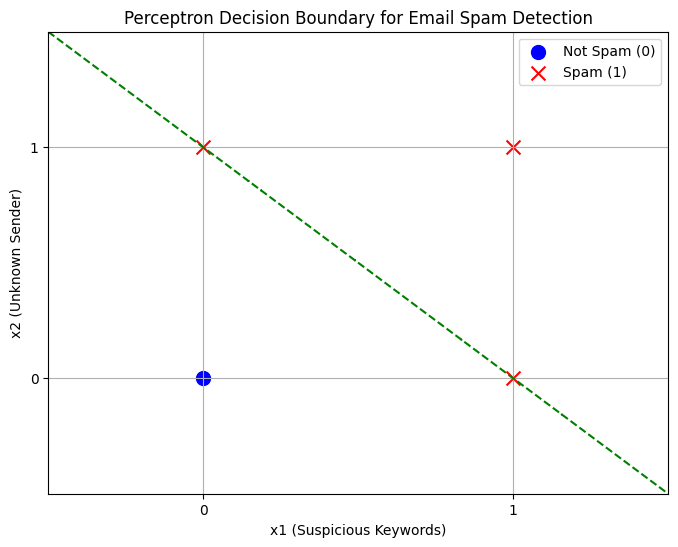

In [7]:
import matplotlib.pyplot as plt

# Create a meshgrid to plot the decision boundary
x1_min, x1_max = -0.5, 1.5
x2_min, x2_max = -0.5, 1.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                       np.linspace(x2_min, x2_max, 100))

# Calculate the Z value for the decision boundary (w1*x1 + w2*x2 + b)
Z = w[0] * xx1 + w[1] * xx2 + b

plt.figure(figsize=(8, 6))

# Plot the data points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Not Spam (0)', marker='o', s=100)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Spam (1)', marker='x', s=100)

# Plot the decision boundary (Z = 0)
plt.contour(xx1, xx2, Z, levels=[0], colors='green', linestyles='--')

plt.xlabel('x1 (Suspicious Keywords)')
plt.ylabel('x2 (Unknown Sender)')
plt.title('Perceptron Decision Boundary for Email Spam Detection')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True)
plt.legend()
plt.show()